# 08 · היסק מבוזר והיתוך מידע (Distributed Inference)
**מלווה את ההרצאה:** *Distributed Inference and Information Fusion* — Pramod Varshney.

> ⚠️ שקופיות הרצאה זו **אינן** ב-PDF. המחברת מבוססת על הספרות הקנונית של גילוי מבוזר 
> (Varshney, *Distributed Detection and Data Fusion*, 1997).

בגילוי **מבוזר**, כל חיישן מקבל החלטה מקומית (ביט) ושולח אותה למרכז היתוך (fusion center) 
במקום את הנתון הגולמי — חוסך רוחב פס. השאלות: איזה **כלל היתוך** למרכז? ואיך נקבעים ה**ספים** המקומיים?

## א. עקומת ROC ופשרת גילוי/אזעקת-שווא
כל חיישן מאופיין ב-$(P_D, P_{FA})$. עבור גילוי אות $A$ ברעש גאוסיאני $\sigma$ עם סף $\tau$:
$$P_{FA}=Q(\tau/\sigma), \qquad P_D=Q((\tau-A)/\sigma), \qquad Q(x)=\tfrac12\operatorname{erfc}(x/\sqrt2)$$
ה-SNR קובע את עקומת ה-ROC — ככל שהיא 'גבוהה' יותר (קרובה לפינה השמאלית-עליונה), הגילוי טוב יותר.

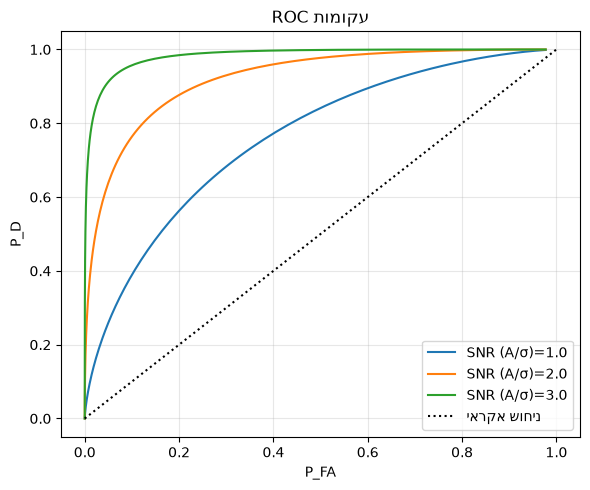

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erfc, sqrt
rng = np.random.default_rng(2)
Q = lambda x: 0.5*erfc(x/sqrt(2))
Qv = np.vectorize(Q)

taus = np.linspace(-2,8,300)
plt.figure(figsize=(6,5))
for A in [1.0, 2.0, 3.0]:
    pfa=Qv(taus); pd=Qv(taus-A)
    plt.plot(pfa,pd,label=f'SNR (A/σ)={A}')
plt.plot([0,1],[0,1],'k:',label='ניחוש אקראי')
plt.xlabel('P_FA'); plt.ylabel('P_D'); plt.title('עקומות ROC'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## ב. כללי היתוך החלטות: AND / OR / רוב (k-out-of-N)
עם $N$ חיישנים בלתי-תלויים מותנית, מרכז ההיתוך מחליט H1 אם לפחות $k$ חיישנים דיווחו '1':
* **OR** ($k=1$) — רגיש מאוד, $P_D$ גבוה אך גם $P_{FA}$ גבוה.
* **AND** ($k=N$) — שמרני, $P_{FA}$ נמוך אך $P_D$ נמוך.
* **רוב** ($k=\lceil N/2\rceil$) — איזון.
$$P_D^{fus}=\sum_{i=k}^{N}\binom{N}{i}P_D^i(1-P_D)^{N-i}$$

חיישן בודד: P_D=0.6, P_FA=0.1
OR (1/5)      P_D=0.990  P_FA=0.4095
רוב (3/5)     P_D=0.683  P_FA=0.0086
AND (5/5)     P_D=0.078  P_FA=0.0000


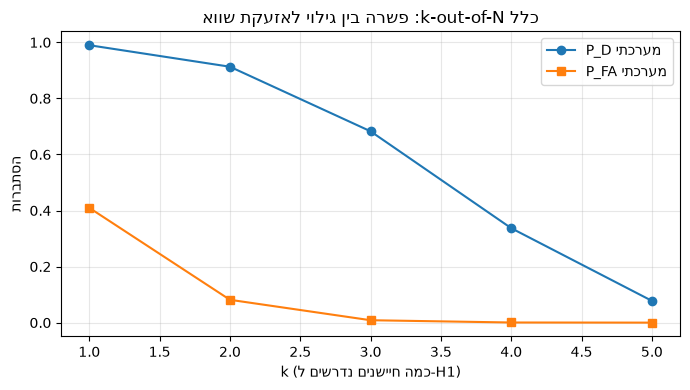

In [2]:
from math import comb
def kN(p, N, k): return sum(comb(N,i)*p**i*(1-p)**(N-i) for i in range(k,N+1))
N=5; pd, pfa = 0.6, 0.1
print(f'חיישן בודד: P_D={pd}, P_FA={pfa}')
for name,k in [('OR (1/5)',1),('רוב (3/5)',3),('AND (5/5)',5)]:
    print(f'{name:12s}  P_D={kN(pd,N,k):.3f}  P_FA={kN(pfa,N,k):.4f}')

ks=range(1,N+1)
plt.figure(figsize=(7,4))
plt.plot(list(ks),[kN(pd,N,k) for k in ks],'o-',label='P_D מערכתי')
plt.plot(list(ks),[kN(pfa,N,k) for k in ks],'s-',label='P_FA מערכתי')
plt.xlabel('k (כמה חיישנים נדרשים ל-H1)'); plt.ylabel('הסתברות')
plt.title('כלל k-out-of-N: פשרה בין גילוי לאזעקת שווא'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## ג. כלל ההיתוך האופטימלי של Chair–Varshney
כשידועים $(P_{D,i},P_{FA,i})$ של כל חיישן, כלל ה-LRT האופטימלי משקלל כל החלטה מקומית $u_i\in\{0,1\}$ 
לפי **אמינותה**:
$$\sum_i \Big[u_i\ln\tfrac{P_{D,i}}{P_{FA,i}} + (1-u_i)\ln\tfrac{1-P_{D,i}}{1-P_{FA,i}}\Big] \;\gtrless\; \ln\tfrac{P_0}{P_1}$$
חיישנים אמינים יותר מקבלים משקל גדול יותר — בניגוד להצבעת רוב 'שווה'.

In [3]:
def chair_varshney(u, PD, PFA, P1=0.5):
    P0=1-P1; s=0.0
    for ui,pd,pf in zip(u,PD,PFA):
        s += np.log(pd/pf) if ui==1 else np.log((1-pd)/(1-pf))
    return 1 if s >= np.log(P0/P1) else 0

# 5 חיישנים הטרוגניים: חלקם אמינים, חלקם רועשים
PD =np.array([0.95,0.9,0.6,0.55,0.7])
PFA=np.array([0.02,0.05,0.3,0.4,0.2])
def majority(u): return 1 if sum(u)>=3 else 0

trials=20000; H1prob=0.5; cv_ok=maj_ok=0
for _ in range(trials):
    H=int(rng.random()<H1prob)
    u=[int(rng.random()<(PD[i] if H else PFA[i])) for i in range(5)]
    cv_ok += chair_varshney(u,PD,PFA)==H
    maj_ok+= majority(u)==H
print(f'דיוק הצבעת רוב     : {maj_ok/trials:.1%}')
print(f'דיוק Chair-Varshney: {cv_ok/trials:.1%}  (משקלל אמינות -> טוב יותר עם חיישנים הטרוגניים)')

דיוק הצבעת רוב     : 93.5%
דיוק Chair-Varshney: 97.8%  (משקלל אמינות -> טוב יותר עם חיישנים הטרוגניים)


## ד. הקשר רחב: consensus וקונפידנס
* **Consensus / gossip** — צמתים ברשת ללא מרכז מתכנסים לאומד גלובלי דרך החלפות מקומיות בלבד.
* **קוונטיזציה** — שליחת ביטים ספורים במקום ערכים מלאים; פשרת רוחב-פס מול דיוק.
* **תקשורת לא-אמינה** — אובדן/השהיית הודעות מחייבים היתוך חסין.
כל אלה הם הכללות מבוזרות של אותו עיקרון: **צבירת מידע מקטינה אי-ודאות** (משוואת ה-Fusion, מחברת 01).

## סיכום
* **ROC** מאפיין כל חיישן; ה-SNR קובע את גבול הביצועים.
* כללי **k-out-of-N** (OR/רוב/AND) נותנים פשרות שונות בין $P_D$ ל-$P_{FA}$.
* **Chair–Varshney** הוא כלל ההיתוך האופטימלי — משקלל לפי אמינות, עדיף על הצבעת רוב כשהחיישנים הטרוגניים.